In [ ]:
!wget https://github.com/CGCL-codes/Amain/raw/refs/heads/main/dataset/GCJ/googlejam4.zip
!wget https://github.com/CGCL-codes/Amain/raw/refs/heads/main/dataset/GCJ/GCJ_clone.csv

--2026-05-25 10:59:21--  https://github.com/CGCL-codes/Amain/raw/refs/heads/main/dataset/GCJ/googlejam4.zip
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/CGCL-codes/Amain/refs/heads/main/dataset/GCJ/googlejam4.zip [following]
--2026-05-25 10:59:22--  https://raw.githubusercontent.com/CGCL-codes/Amain/refs/heads/main/dataset/GCJ/googlejam4.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1193493 (1.1M) [application/zip]
Saving to: ‘googlejam4.zip.1’

googlejam4.zip.1    100%[===================>]   1.14M  --.-KB/s    in 0.1s    

2026-05-25 10:59:22 (9.06 MB/s) - ‘googlejam4.zip.1’ saved [11

In [7]:
!mkdir GCJ
!unzip googlejam4.zip -d GCJ

mkdir: cannot create directory ‘GCJ’: File exists
Archive:  googlejam4.zip
   creating: GCJ/googlejam4/
  inflating: GCJ/googlejam4/googlejam1.p003.Mushroom.java  
  inflating: GCJ/googlejam4/googlejam1.p006.A.java  
  inflating: GCJ/googlejam4/googlejam1.p011.taskA.java  
  inflating: GCJ/googlejam4/googlejam1.p012.A.java  
  inflating: GCJ/googlejam4/googlejam1.p013.A.java  
  inflating: GCJ/googlejam4/googlejam1.p015.A.java  
  inflating: GCJ/googlejam4/googlejam1.p019.Mushroom.java  
  inflating: GCJ/googlejam4/googlejam1.p021.mushroom.java  
  inflating: GCJ/googlejam4/googlejam1.p022.A.java  
  inflating: GCJ/googlejam4/googlejam1.p024.A.java  
  inflating: GCJ/googlejam4/googlejam1.p025.ProblemA.java  
  inflating: GCJ/googlejam4/googlejam1.p026.Mushrooms.java  
  inflating: GCJ/googlejam4/googlejam1.p027.A.java  
  inflating: GCJ/googlejam4/googlejam1.p030.A.java  
  inflating: GCJ/googlejam4/googlejam1.p032.A.java  
  inflating: GCJ/googlejam4/googlejam1.p033.A.java  
  inflat

In [20]:
import pandas as pd
import numpy as np
from collections import defaultdict
import random

np.random.seed(42)
random.seed(42)

# =============================================
# 1. Wczytanie i budowa grup
# =============================================
clones = pd.read_csv("GCJ/GCJ_clone.csv", header=None)
clones[0] = clones[0].astype(str)
clones[1] = clones[1].astype(str)

graph = defaultdict(set)
for _, row in clones.iterrows():
    x, y = row.iloc[0], row.iloc[1]
    graph[x].add(y)
    graph[y].add(x)

visited = set()
clone_index = {}
current_index = 0

def dfs(start, idx):
    stack = [start]
    while stack:
        node = stack.pop()
        if node in visited: continue
        visited.add(node)
        clone_index[node] = idx
        for neigh in graph[node]:
            if neigh not in visited:
                stack.append(neigh)

for node in list(graph.keys()):
    if node not in visited:
        current_index += 1
        dfs(node, current_index)

codes_count = defaultdict(int)
for idx in clone_index.values():
    codes_count[idx] += 1

sorted_groups = sorted(codes_count.items(), key=lambda x: x[1])
train_indices = {sorted_groups[0][0], sorted_groups[1][0]}

test_indices = [idx for idx in codes_count if idx not in train_indices]

# =============================================
# 2. Lepsze zrównoważone wybieranie par
# =============================================
used_codes = set()
selected_clone_pairs = []
selected_non_clone_pairs = []

test_codes_by_group = defaultdict(list)
for code, idx in clone_index.items():
    if idx in test_indices:
        test_codes_by_group[idx].append(code)

# --- 1. Clone pairs - staramy się rozłożyć po grupach ---
all_clone_pairs = []
for _, row in clones.iterrows():
    x, y = row.iloc[0], row.iloc[1]
    if clone_index.get(x) in test_indices and clone_index.get(y) in test_indices:
        all_clone_pairs.append((x, y, clone_index[x], clone_index[y]))

random.shuffle(all_clone_pairs)

# Wybieramy 50 par klonów starając się nie dominować jednej grupy
group_clone_count = defaultdict(int)

for x, y, idx1, idx2 in all_clone_pairs:
    if x in used_codes or y in used_codes:
        continue
    # Ograniczamy ile razy grupa może być użyta w parach klonów
    if group_clone_count[idx1] < 12 and group_clone_count[idx2] < 12:   # limit na grupę
        selected_clone_pairs.append((x, y, idx1, idx2))
        used_codes.add(x)
        used_codes.add(y)
        group_clone_count[idx1] += 1
        group_clone_count[idx2] += 1
    if len(selected_clone_pairs) >= 50:
        break

print(f"Wybrano {len(selected_clone_pairs)} par klonów")

# --- 2. Non-clone pairs - balansujemy względem clone pairs ---
group_nonclone_count = defaultdict(int)

for _ in range(30000):
    idx1 = random.choice(test_indices)
    idx2 = random.choice(test_indices)
    if idx1 == idx2:
        continue

    code1 = random.choice(test_codes_by_group[idx1])
    code2 = random.choice(test_codes_by_group[idx2])

    if code1 in used_codes or code2 in used_codes:
        continue

    # Staramy się zrównoważyć liczebność indeksu
    if (group_nonclone_count[idx1] < group_clone_count[idx1] + 3 and 
        group_nonclone_count[idx2] < group_clone_count[idx2] + 3):
        
        selected_non_clone_pairs.append((code1, code2, idx1, idx2))
        used_codes.add(code1)
        used_codes.add(code2)
        group_nonclone_count[idx1] += 1
        group_nonclone_count[idx2] += 1

    if len(selected_non_clone_pairs) >= 50:
        break

print(f"Wybrano {len(selected_non_clone_pairs)} par non-klonów")

# =============================================
# 3. Zapis
# =============================================
clone_df = pd.DataFrame(selected_clone_pairs, columns=['code1', 'code2', 'code1_clone_index', 'code2_clone_index'])
clone_df['label'] = 1

non_df = pd.DataFrame(selected_non_clone_pairs, columns=['code1', 'code2', 'code1_clone_index', 'code2_clone_index'])
non_df['label'] = 0

test_dataset = pd.concat([clone_df, non_df], ignore_index=True)
test_dataset = test_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

test_dataset.to_csv("test_dataset_50_50.csv", index=False)

print("\n=== ZAPISANO ===")
print(f"Plik: test_dataset_50_50.csv")

Wybrano 50 par klonów
Wybrano 50 par non-klonów

=== ZAPISANO (zbalansowana wersja) ===
Plik: test_dataset_50_50_balanced.csv


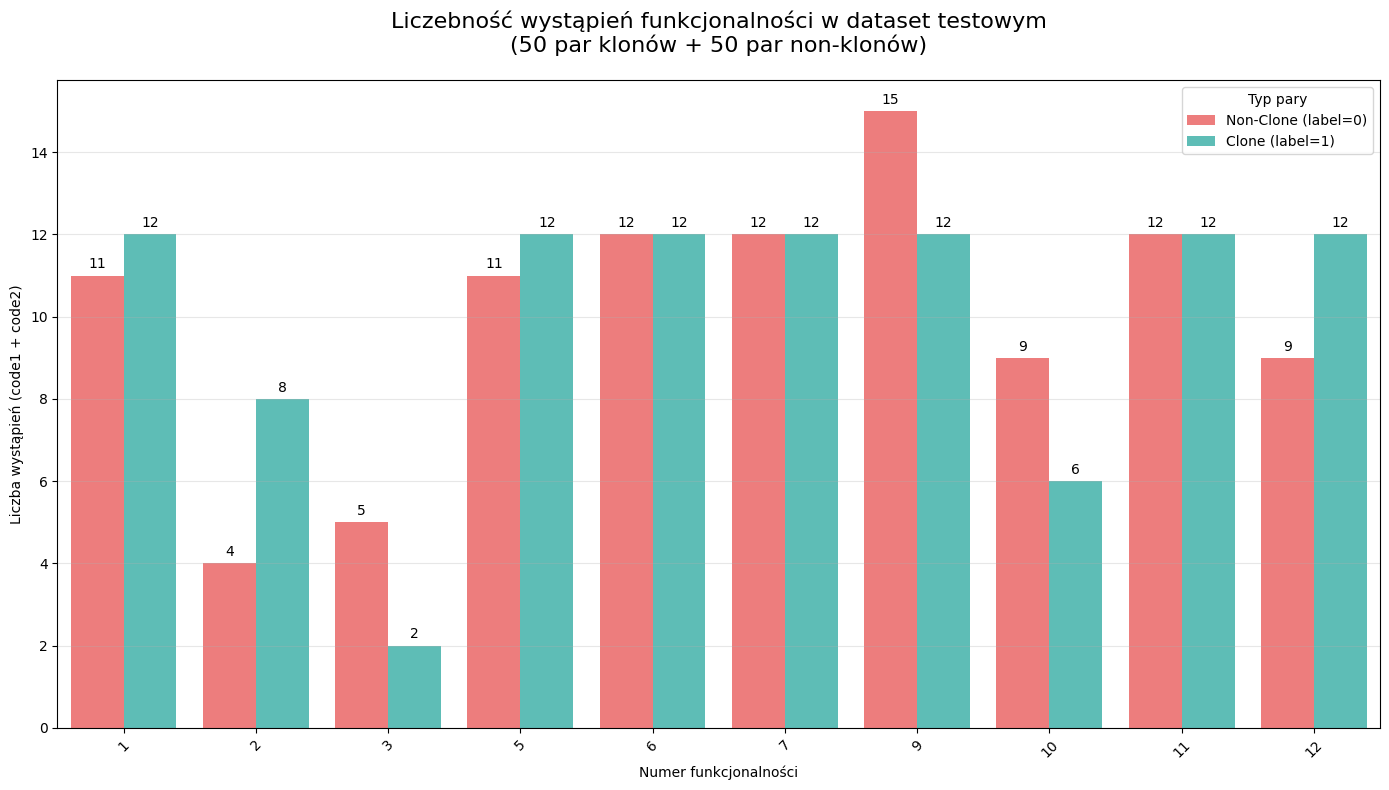

=== STATYSTYKI ===
code1_clone_index
1     12
2      5
3      4
5     12
6      9
7     10
9     14
10     6
11    15
12    13
Name: count, dtype: int64

Liczba unikalnych clone_index w teście: 10


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytaj dataset
df = pd.read_csv("test_dataset_50_50.csv")

# Przygotowanie danych do wykresu
df_melt = pd.melt(df, 
                  id_vars=['label'], 
                  value_vars=['code1_clone_index', 'code2_clone_index'],
                  var_name='position', 
                  value_name='clone_index')

# Mapowanie label na czytelną nazwę
df_melt['type'] = df_melt['label'].map({1: 'Clone (label=1)', 0: 'Non-Clone (label=0)'})

# Liczebność dla każdego clone_index
plt.figure(figsize=(14, 8))
sns.countplot(data=df_melt, x='clone_index', hue='type', palette=['#ff6b6b', '#4ecdc4'])

plt.title('Liczebność wystąpień funkcjonalności w dataset testowym\n(50 par klonów + 50 par non-klonów)', 
          fontsize=16, pad=20)
plt.xlabel('Numer funkcjonalności')
plt.ylabel('Liczba wystąpień (code1 + code2)')
plt.legend(title='Typ pary')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Dodanie wartości nad słupkami
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig("clone_index_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

# Statystyki
print("=== STATYSTYKI ===")
print(df['code1_clone_index'].value_counts().sort_index().head(10))
print("\nLiczba unikalnych clone_index w teście:", df['code1_clone_index'].nunique())